<a href="https://colab.research.google.com/github/ADRITATITIR/airline-sentiment-analysis-/blob/main/airline_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
dataset = pd.read_csv('/content/Tweets.csv')

In [4]:
dataset.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


**#return percentage of every columns missing value , cols which have >90% missing values then drop them**

In [6]:
(len(dataset) - dataset.count())/len(dataset)

,0
tweet_id,0.000000
airline_sentiment,0.000000
airline_sentiment_confidence,0.000000
negativereason,0.373087
negativereason_confidence,0.281284
airline,0.000000
airline_sentiment_gold,0.997268
name,0.000000
negativereason_gold,0.997814
retweet_count,0.000000


In [7]:
dataset = dataset.drop(['airline_sentiment_gold','negativereason_gold','tweet_coord'],axis=1)

In [8]:
dataset.head(3)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [9]:
mood_count=dataset['airline_sentiment'].value_counts()

In [10]:
mood_count

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

**Graphical representation of airline sentiment :-**

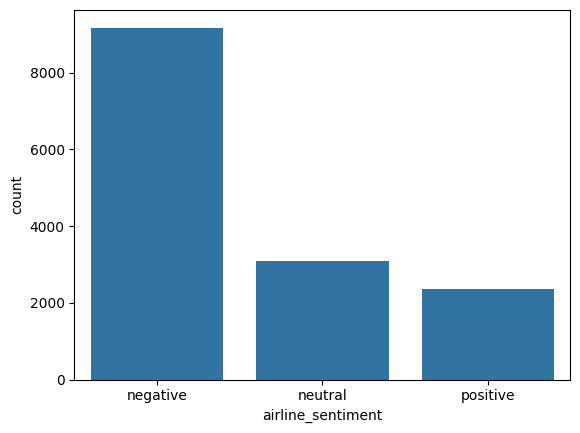

In [12]:
sns.countplot(x='airline_sentiment',data=dataset,order=['negative','neutral','positive'])
plt.show()

**Graphical representation of airline sentiment with airlines:-**

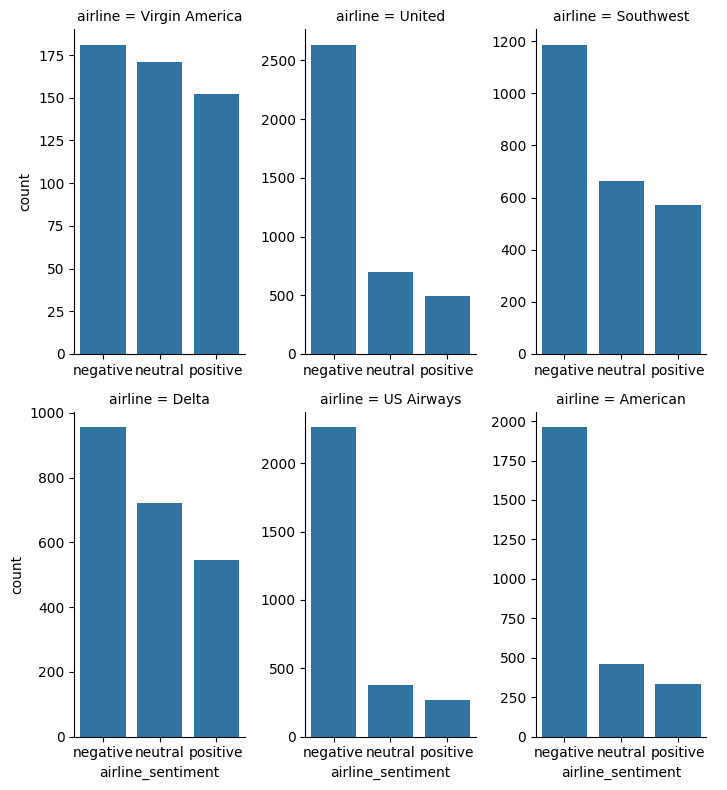

In [16]:
sns.catplot(
    x='airline_sentiment',
    data=dataset,
    order=['negative', 'neutral', 'positive'],
    kind='count',
    col='airline',
    col_wrap=3,
    height=4,
    aspect=0.6,
    sharex=False,
    sharey=False
)

plt.show()

In [15]:
dataset['negativereason'].value_counts()

,count
negativereason,
Customer Service Issue,2910
Late Flight,1665
Can't Tell,1190
Cancelled Flight,847
Lost Luggage,724
Bad Flight,580
Flight Booking Problems,529
Flight Attendant Complaints,481
longlines,178


**Graphical representation of negativereason towards airlines:-**

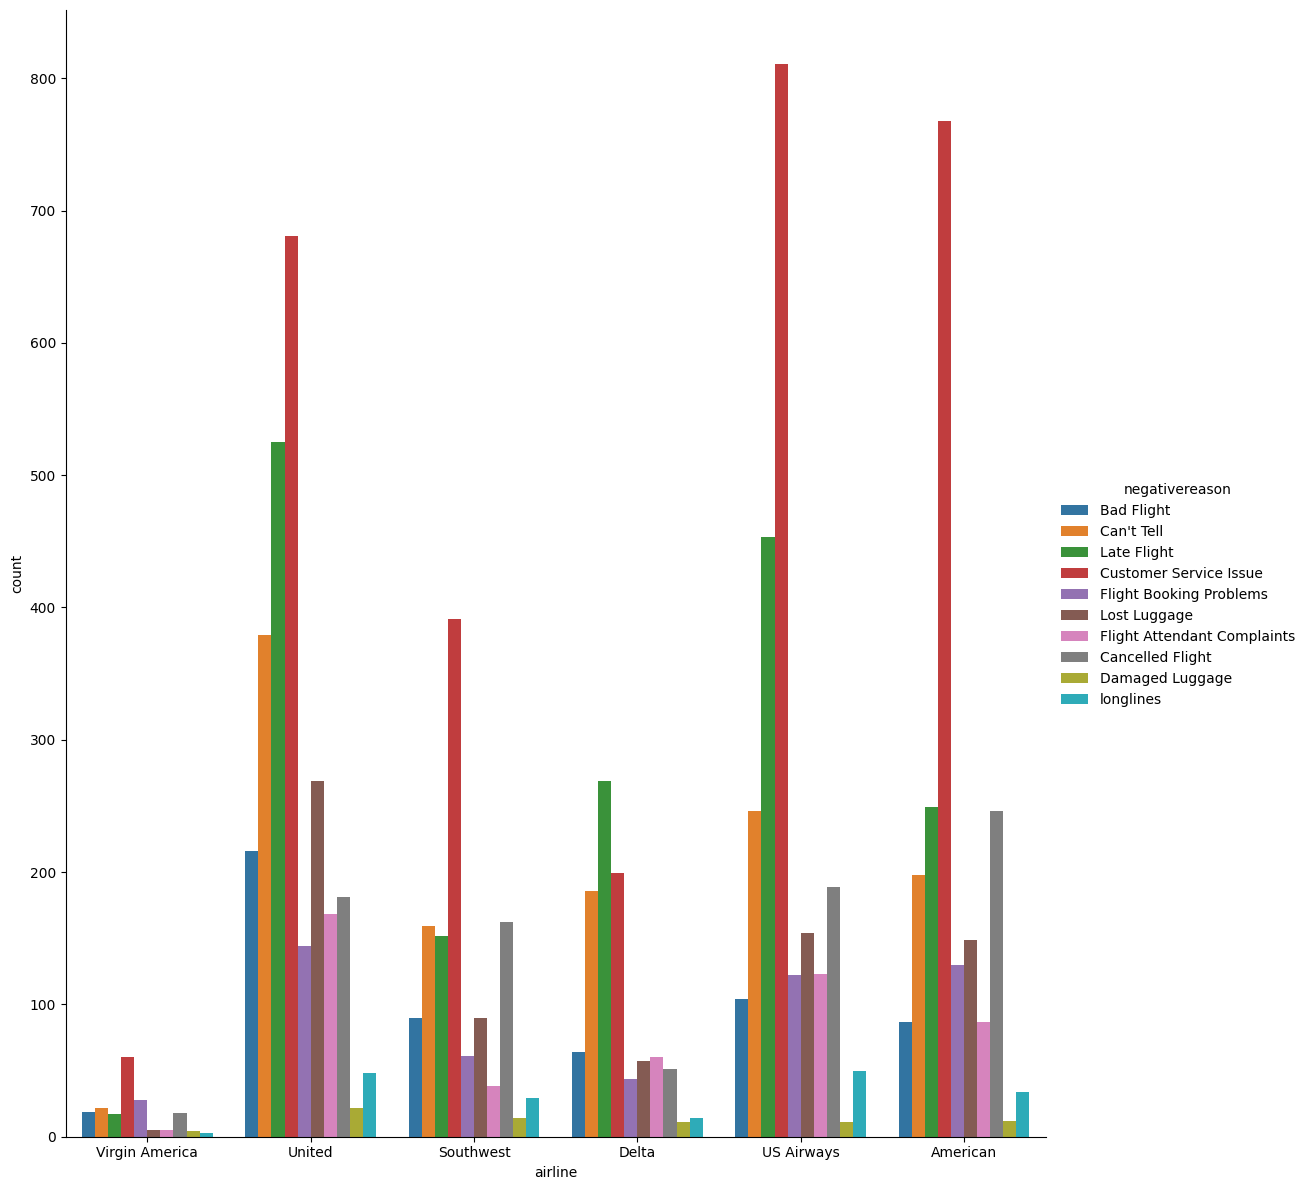

In [18]:
sns.catplot(
    x='airline',
    data=dataset,
    kind='count',
    hue='negativereason',
    height=12,
    aspect=.9
)

plt.show()

both above and below graph are same and for show the negative comment reason on different airlines

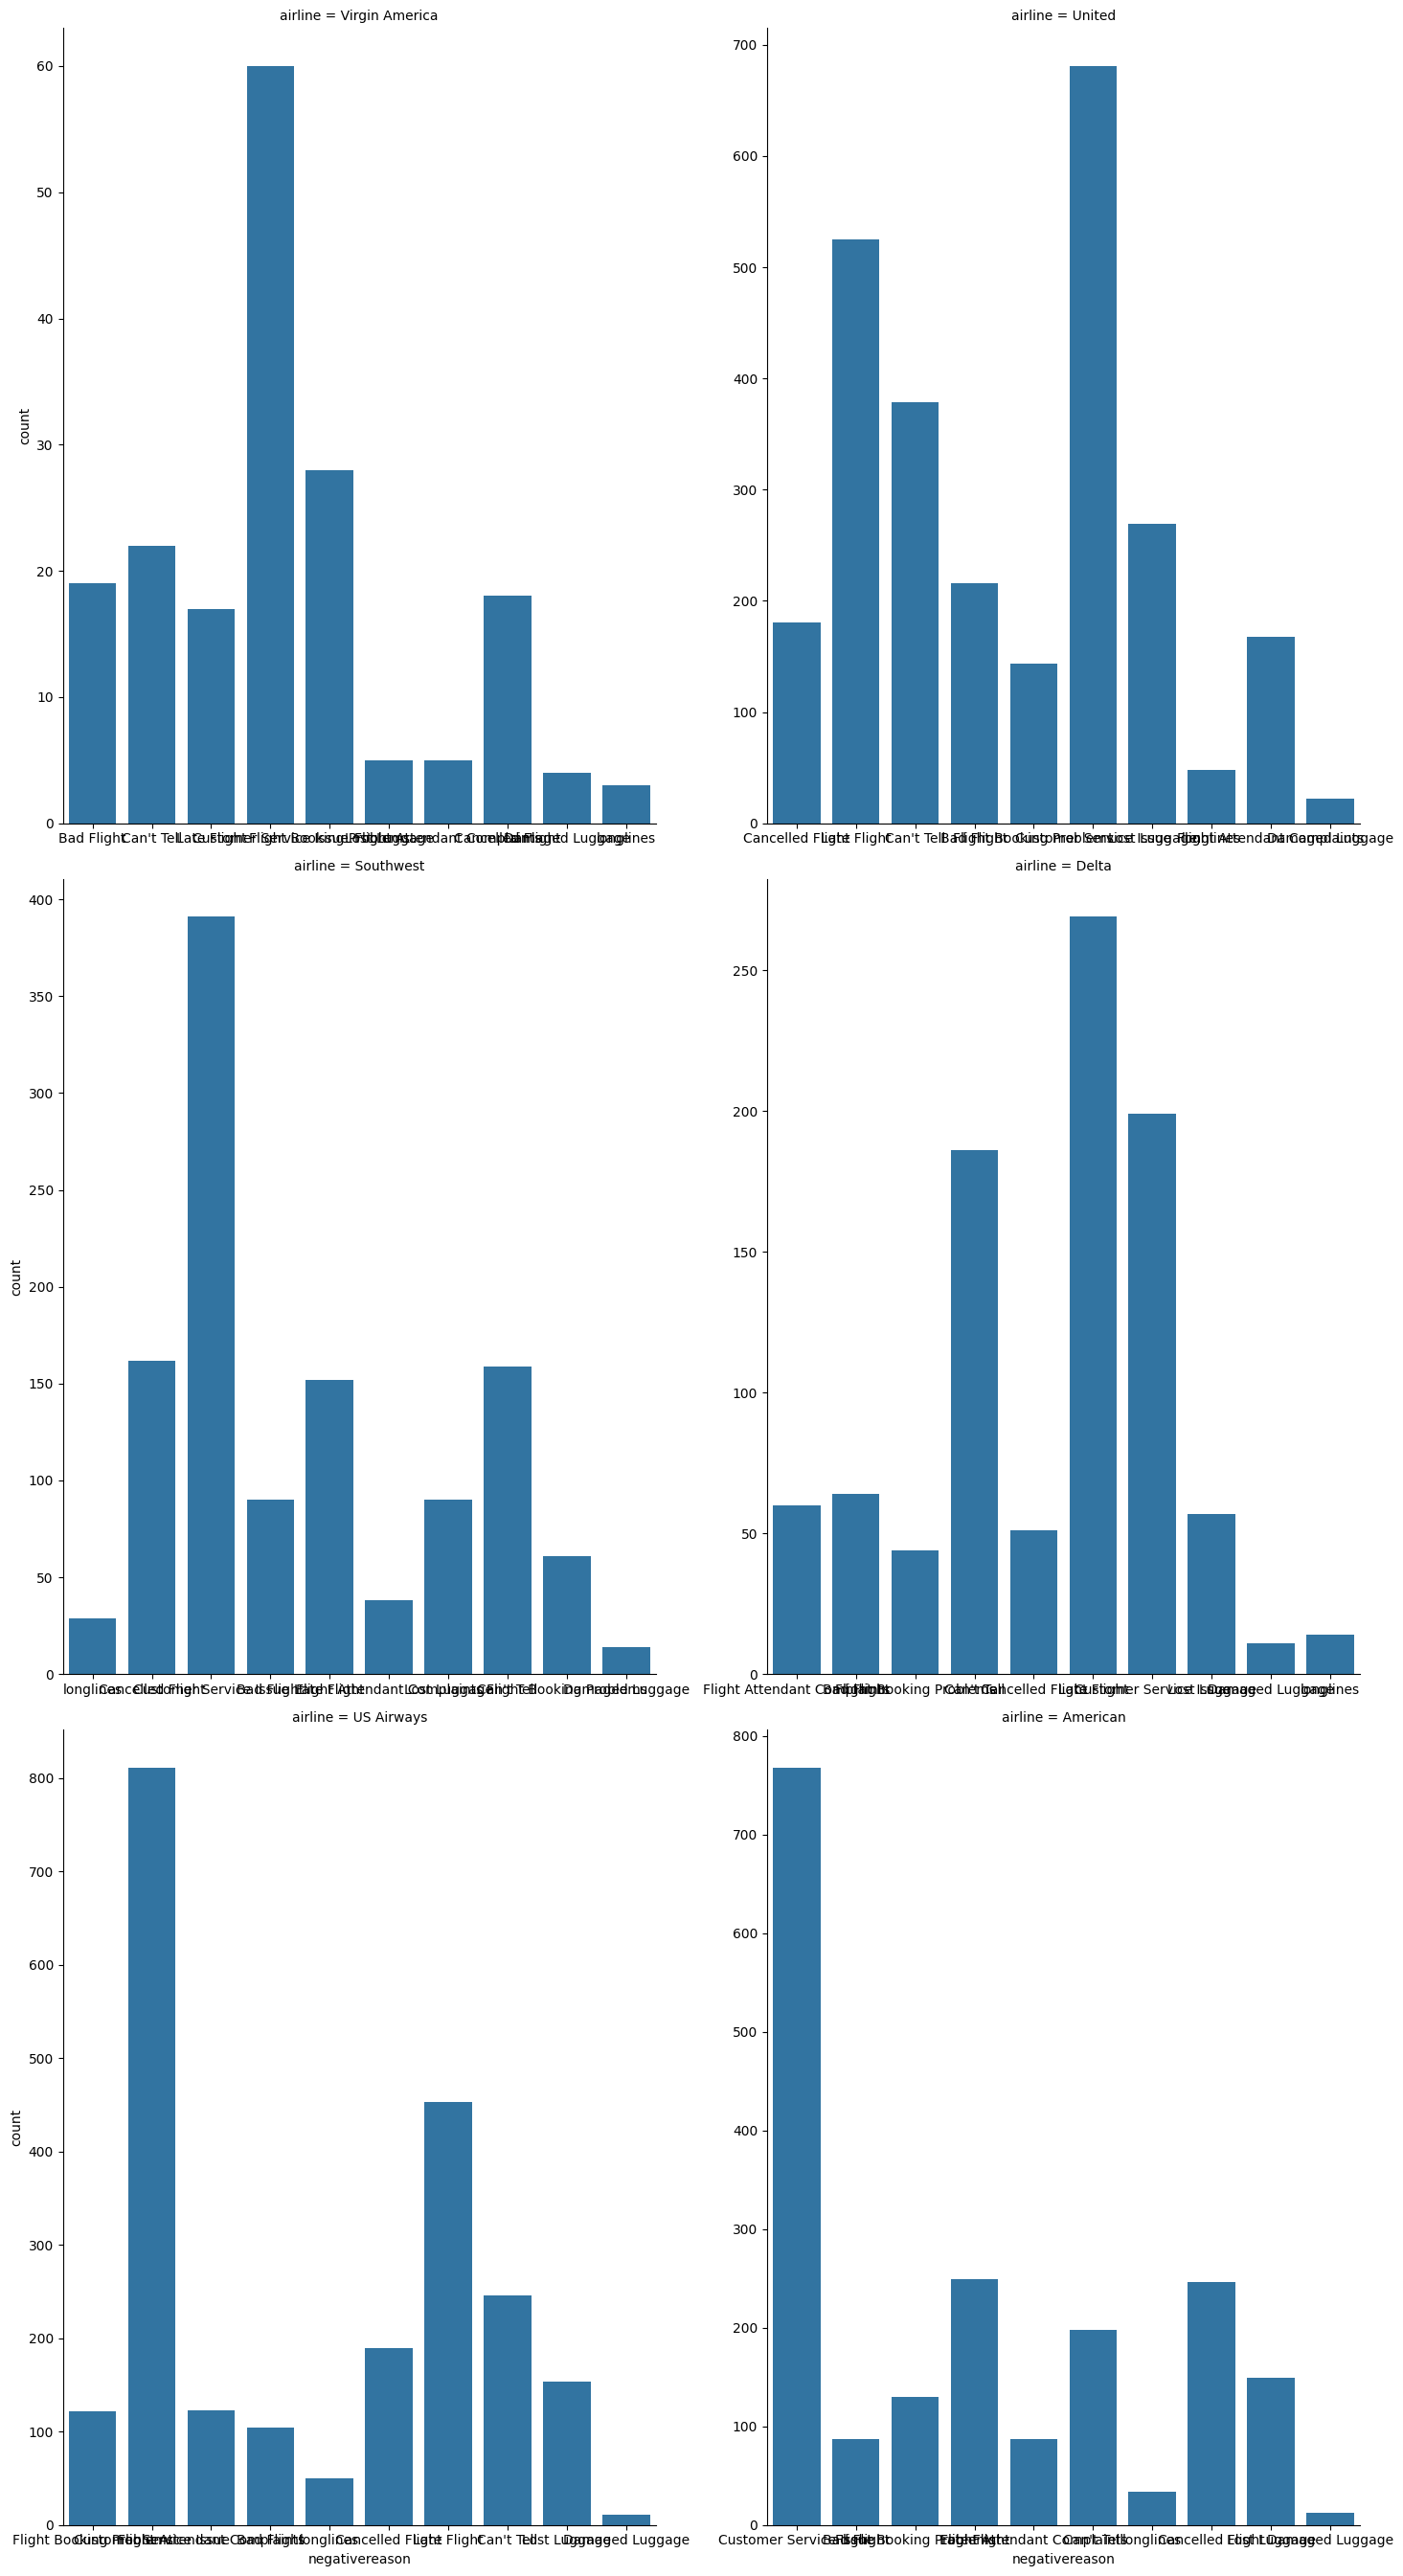

In [20]:
sns.catplot(
    x='negativereason',
    data=dataset,
    kind='count',
    col='airline',
    height=9,
    aspect=.8,
    col_wrap=2,
    sharex=False,
    sharey=False
)

plt.show()

**Data Cleaning and Preprocessing :-**

In [21]:
import re
import nltk
import time

In [22]:
start_time = time.time()
#remove words which are starts with @ symbols
dataset['text'] = dataset['text'].map(lambda x:re.sub('@\w*','',str(x)))
#remove special characters except [a-zA-Z]
dataset['text'] = dataset['text'].map(lambda x:re.sub('[^a-zA-Z]',' ',str(x)))
#remove link starts with https
dataset['text'] = dataset['text'].map(lambda x:re.sub('http.*','',str(x)))
end_time = time.time()

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_179/23034443.py:3: SyntaxWarning: invalid escape sequence '\w'
  dataset['text'] = dataset['text'].map(lambda x:re.sub('@\w*','',str(x)))


In [23]:
#total time consume to filter data
end_time-start_time

0.17287325859069824

In [24]:
dataset['text'].head()

,text
0,What said
1,plus you ve added commercials to the experien...
2,I didn t today Must mean I need to take an...
3,it s really aggressive to blast obnoxious en...
4,and it s a really big bad thing about it


In [25]:
dataset['text'] = dataset['text'].map(lambda x:str(x).lower())

In [26]:
dataset['text'].head(2)

,text
0,what said
1,plus you ve added commercials to the experien...


In [27]:
from nltk.corpus import stopwords

In [28]:
corpus = []

* Remove stopwords from comments
* Not used  PorterStemmer to make words pure

In [30]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
corpus[:4]

**Training Part :-**

In [31]:
X = pd.DataFrame(data=corpus,columns=['comment_text'])

In [32]:
X.head()

,comment_text


In [33]:
y = dataset['airline_sentiment'].map({'neutral':1,'negative':-1,'positive':1})

In [34]:
y.head(2)

,airline_sentiment
0,1
1,1


Split data into Train and Test:-

In [35]:
from sklearn.model_selection import train_test_split

In [58]:
X = dataset['text']
y = dataset['airline_sentiment']

print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(dataset.columns)


(14640,)
(14640,)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline', 'name',
       'retweet_count', 'text', 'tweet_created', 'tweet_location',
       'user_timezone'],
      dtype='object')


In [59]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(11712,) (2928,) (11712,) (2928,)


Use TfidfVectorizer for feature extraction :-

In [61]:
from sklearn.feature_extraction.text import CountVectorizer

In [62]:
vector = CountVectorizer(stop_words='english')  # removes common stopwords

In [63]:
# Fit on training data and transform it
X_train_word_feature = vector.fit_transform(X_train).toarray()


In [64]:
X_test_word_feature = vector.transform(X_test).toarray()

In [65]:
print(X_test_word_feature.shape,X_test_word_feature.shape)

(2928, 9697) (2928, 9697)


Model Training :-

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [47]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [67]:
classifier = LogisticRegression()
X = dataset['text']
y = dataset['airline_sentiment']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [70]:
vector = CountVectorizer(stop_words='english')
X_train_word_feature = vector.fit_transform(X_train).toarray()  # fit on train
X_test_word_feature = vector.transform(X_test).toarray()        # transform test
print(X_train_word_feature.shape, X_test_word_feature.shape)

# 5️⃣ Initialize and train Logistic Regression
classifier = LogisticRegression(max_iter=1000)  # increase max_iter if convergence warnings appear
classifier.fit(X_train_word_feature, y_train)

# 6️⃣ Predict on test set
y_pred = classifier.predict(X_test_word_feature)

# 7️⃣ Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

(11712, 9697) (2928, 9697)
Accuracy: 0.7721994535519126
Confusion Matrix:
 [[1632  187   51]
 [ 228  339   47]
 [  99   55  290]]
Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.87      0.85      1870
     neutral       0.58      0.55      0.57       614
    positive       0.75      0.65      0.70       444

    accuracy                           0.77      2928
   macro avg       0.72      0.69      0.71      2928
weighted avg       0.77      0.77      0.77      2928



In [71]:
from sklearn.metrics import confusion_matrix

# Make sure y_pred exists and is aligned with y_test
# y_pred should be obtained from classifier.predict
y_pred = classifier.predict(X_test_word_feature)

# Both y_test and y_pred should be 1-D arrays of the same length
print(y_test.shape, y_pred.shape)  # check shapes

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

(2928,) (2928,)
[[1632  187   51]
 [ 228  339   47]
 [  99   55  290]]


In [72]:
acc_score = accuracy_score(y_test,y_pred)

In [73]:
print(classification_report(y_test,y_pred),'\n',cm,'\n',acc_score)

              precision    recall  f1-score   support

    negative       0.83      0.87      0.85      1870
     neutral       0.58      0.55      0.57       614
    positive       0.75      0.65      0.70       444

    accuracy                           0.77      2928
   macro avg       0.72      0.69      0.71      2928
weighted avg       0.77      0.77      0.77      2928
 
 [[1632  187   51]
 [ 228  339   47]
 [  99   55  290]] 
 0.7721994535519126


In [74]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the classifier
classifier = LogisticRegression(max_iter=1000)

# 2. Fit the classifier
classifier.fit(X_train_word_feature, y_train)

# 3. Predict probabilities (for each class)
y_pred_prob = classifier.predict_proba(X_test_word_feature)

# 4. Check shape
print(y_pred_prob.shape)  # should be (num_samples, num_classes)

(2928, 3)


To determine probability of negative or positive comment :-

In [75]:
y_pred_prob[:5]

array([[9.85020903e-01, 1.43501853e-02, 6.28911710e-04],
       [9.25834786e-01, 6.98687600e-02, 4.29645354e-03],
       [9.85941485e-01, 1.05701859e-02, 3.48832959e-03],
       [3.27787708e-01, 5.91877636e-01, 8.03346556e-02],
       [1.79887689e-01, 2.40023798e-02, 7.96109931e-01]])